# Delay-and-Sum Beamforming Utility

Delay-and-sum beamforming is the fundamental array processing method used in sonar, radar, and microphone arrays.

---

## 1. Theory

- **Goal:** Steer the array's sensitivity to a desired direction by time-shifting (delaying) each channel so that plane waves from that angle add up coherently.
- **In sonar:** Used for direction finding, noise rejection, and improving SNR.

---


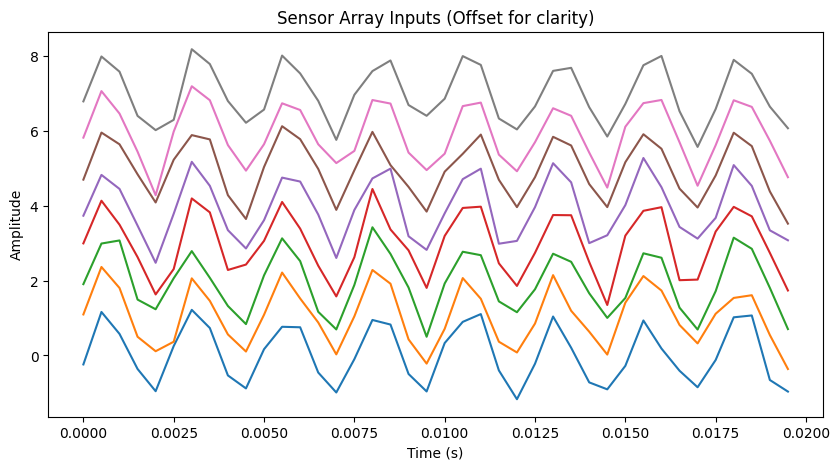

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 2000
duration = 0.02
t = np.arange(0, duration, 1/fs)
n_elements = 8
d = 0.03  # 3cm spacing
array_pos = np.arange(n_elements) * d
sound_speed = 1500  # m/s
f_sig = 400  # signal frequency (Hz)

# Signal: plane wave from 30 deg
theta_deg = 30
theta_rad = np.deg2rad(theta_deg)
delay = (array_pos * np.sin(theta_rad)) / sound_speed
signals = np.array([np.sin(2*np.pi*f_sig*(t - dly)) for dly in delay])
# Add noise
signals += 0.25 * np.random.randn(*signals.shape)

# Plot sensor signals
plt.figure(figsize=(10,5))
for i in range(n_elements):
    plt.plot(t, signals[i] + i, label=f'Element {i+1}')  # Offset for clarity
plt.title('Sensor Array Inputs (Offset for clarity)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()


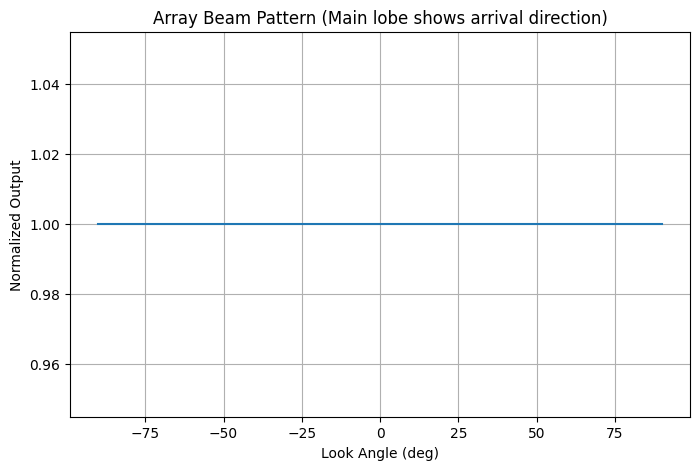

In [2]:
def delay_and_sum(signals, fs, d, angles_scan, sound_speed=1500):
    n_elements, n_samples = signals.shape
    t = np.arange(n_samples) / fs
    array_pos = np.arange(n_elements) * d
    output = []
    for angle in angles_scan:
        theta_rad = np.deg2rad(angle)
        delays = (array_pos * np.sin(theta_rad)) / sound_speed
        aligned = np.zeros_like(signals)
        for i in range(n_elements):
            shift_samples = int(round(delays[i] * fs))
            if shift_samples >= 0:
                aligned[i, shift_samples:] = signals[i, :-shift_samples or None]
            else:
                aligned[i, :shift_samples] = signals[i, -shift_samples:]
        output.append(np.sum(aligned, axis=0))
    return np.array(output)

angles_scan = np.linspace(-90, 90, 181)
beam_out = delay_and_sum(signals, fs, d, angles_scan, sound_speed)

# Compute beam power (normalize)
beam_power = np.max(np.abs(beam_out), axis=1)
beam_power /= np.max(beam_power)

plt.figure(figsize=(8,5))
plt.plot(angles_scan, beam_power)
plt.title('Array Beam Pattern (Main lobe shows arrival direction)')
plt.xlabel('Look Angle (deg)')
plt.ylabel('Normalized Output')
plt.grid()
plt.show()


## Notes
- Main lobe in the beampattern corresponds to arrival angle of the signal.
- This demo is for a uniform linear array (ULA); can be adapted to other array types or real data.

---
**Use this code to simulate or analyze your own array, test robustness to noise, or visualize array performance for your interview or GitHub!**
